<a href="https://colab.research.google.com/github/KaveyaEzhil/Machine-Learning/blob/main/ML_ITA0613.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 1 — FIND-S Algorithm

In [ ]:
import pandas as pd
from google.colab import files


uploaded = files.upload()

# Read the uploaded CSV file
data = pd.read_csv("data.csv")

# Initialize hypothesis
h = []

# Find the first positive example
for i in range(len(data)):
    if data.iloc[i, -1] == "Yes":
        h = list(data.iloc[i, :-1])
        break

# Compare all positive examples
for i in range(len(data)):
    if data.iloc[i, -1] == "Yes":
        for j in range(len(h)):
            if h[j] != data.iloc[i, j]:
                h[j] = "?"

# Print the final hypothesis
print("Most specific hypothesis:")
print(h)

Saving data.csv to data.csv
Most specific hypothesis:
['Sunny', 'Warm', '?', '?']


Lab 2 — Candidate-Elimination Algorithm

In [ ]:
import pandas as pd
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Read CSV file
data = pd.read_csv(file_name)

# Convert data into list
data = data.values.tolist()

# Number of attributes
n = len(data[0]) - 1

# Initialize S as most specific
S = ['0'] * n

# Initialize G as most general
G = [['?'] * n]

# Process each training example
for row in data:
    x = row[:-1]
    y = row[-1]

    # Positive example
    if y == "Yes":

        # Generalize S
        for i in range(n):
            if S[i] == '0':
                S[i] = x[i]
            elif S[i] != x[i]:
                S[i] = '?'

        # Remove inconsistent hypotheses from G
        G = [g for g in G if all(g[i] == '?' or g[i] == x[i] for i in range(n))]

    # Negative example
    elif y == "No":

        new_G = []

        for g in G:
            for i in range(n):
                if g[i] == '?':
                    for value in set([row[i] for row in data]):
                        if value != x[i]:
                            new_g = g.copy()
                            new_g[i] = value
                            new_G.append(new_g)

        G = new_G

# Print results
print("Final S Boundary:")
print(S)

print("\nFinal G Boundary:")
for g in G:
    print(g)

Saving data.csv to data (1).csv
Final S Boundary:
['Sunny', 'Warm', '?', '?']

Final G Boundary:
['Sunny', '?', '?', '?']
['?', 'Warm', '?', '?']
['?', '?', '?', 'Weak']


Lab 3 — Decision Tree Learning (ID3) from Scratch

In [ ]:
import pandas as pd
import math
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Get file name
file_name = list(uploaded.keys())[0]

# Read CSV file
data = pd.read_csv(file_name)


# Function to calculate entropy
def entropy(data):
    target = data.iloc[:, -1]
    values = target.value_counts()

    e = 0

    for count in values:
        p = count / len(target)
        e = e - p * math.log2(p)

    return e


# Function to calculate information gain
def information_gain(data, attribute):
    total_entropy = entropy(data)

    values = data[attribute].unique()

    weighted_entropy = 0

    for value in values:
        subset = data[data[attribute] == value]

        weighted_entropy += (len(subset) / len(data)) * entropy(subset)

    gain = total_entropy - weighted_entropy

    return gain


# Function to build decision tree
def id3(data, attributes):

    # Get target column
    target = data.columns[-1]

    # If all values belong to one class
    if len(data[target].unique()) == 1:
        return data[target].iloc[0]

    # If no attributes are left
    if len(attributes) == 0:
        return data[target].mode()[0]

    # Find attribute with maximum information gain
    best_attribute = ""

    max_gain = -1

    for attribute in attributes:
        gain = information_gain(data, attribute)

        if gain > max_gain:
            max_gain = gain
            best_attribute = attribute

    # Create tree
    tree = {best_attribute: {}}

    # Get all values of best attribute
    values = data[best_attribute].unique()

    for value in values:

        subset = data[data[best_attribute] == value]

        remaining_attributes = attributes.copy()
        remaining_attributes.remove(best_attribute)

        tree[best_attribute][value] = id3(
            subset,
            remaining_attributes
        )

    return tree


# Attributes except target column
attributes = list(data.columns[:-1])

# Build the decision tree
tree = id3(data, attributes)

print("Decision Tree:")
print(tree)


# Function to classify a new sample
def classify(tree, sample):

    if not isinstance(tree, dict):
        return tree

    attribute = list(tree.keys())[0]

    value = sample[attribute]

    return classify(tree[attribute][value], sample)


# Enter a new sample
sample = {}

for attribute in attributes:
    sample[attribute] = input("Enter " + attribute + ": ")

# Predict result
result = classify(tree, sample)

print("\nClassification Result:", result)

Saving data.csv to data (2).csv
Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}
Enter Outlook: Sunny
Enter Temperature: Cool
Enter Humidity: High
Enter Wind: String

Classification Result: No


Lab 4 — Decision Tree using scikit-learn with Visualisation

Accuracy: 1.0


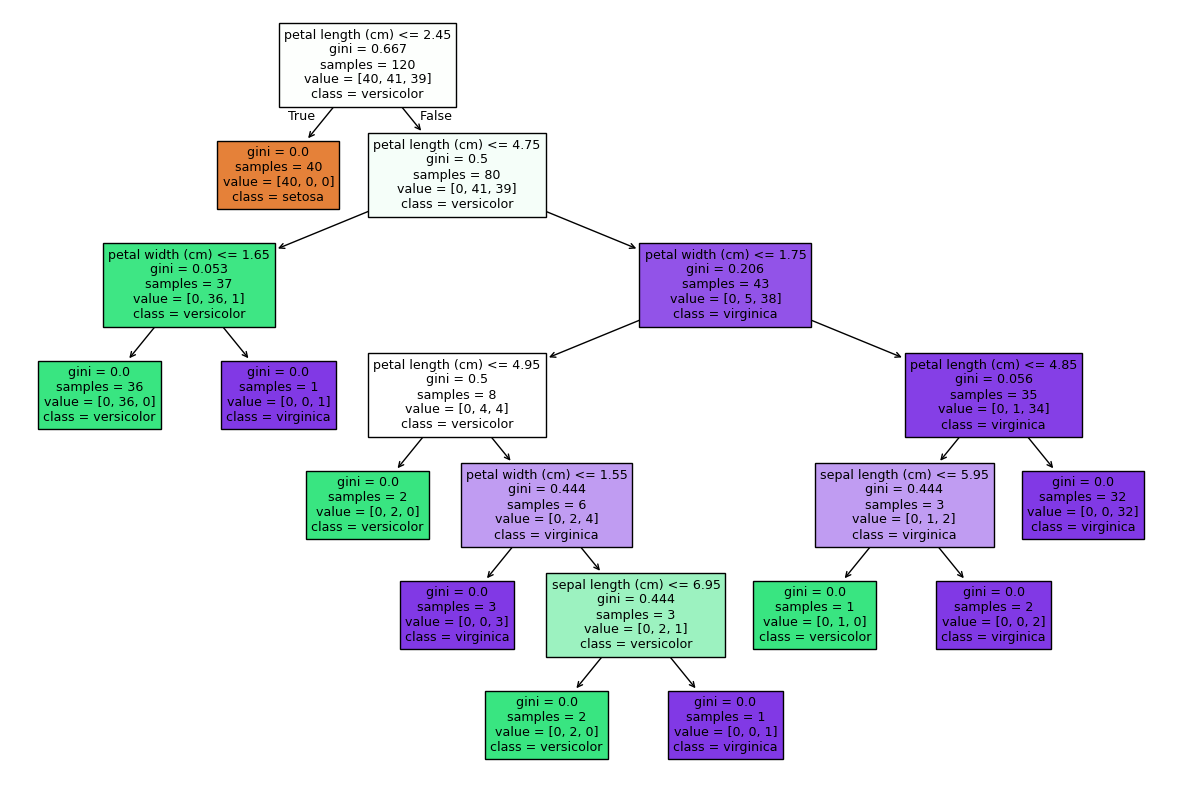

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Decision Tree model
model = DecisionTreeClassifier()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Visualize the Decision Tree
plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

Lab 5 — Single-Layer Perceptron (AND / OR Gate)

In [6]:
# Single Layer Perceptron for AND and OR Gate

def perceptron(x, y, w, b, lr, epochs):

    for e in range(epochs):

        for i in range(len(x)):

            # Calculate sum
            s = x[i][0] * w[0] + x[i][1] * w[1] + b

            # Threshold function
            if s >= 0:
                o = 1
            else:
                o = 0

            # Calculate error
            error = y[i] - o

            # Update weights and bias
            w[0] = w[0] + lr * error * x[i][0]
            w[1] = w[1] + lr * error * x[i][1]
            b = b + lr * error

    return w, b


# Input values
x = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]


# Choose AND or OR
choice = input("Enter AND or OR: ").upper()


if choice == "AND":
    y = [0, 0, 0, 1]

elif choice == "OR":
    y = [0, 1, 1, 1]

else:
    print("Invalid choice")
    y = []


if y:

    # Initial weights
    w = [0, 0]

    # Initial bias
    b = 0

    # Learning rate
    lr = 0.1

    # Train perceptron
    w, b = perceptron(x, y, w, b, lr, 10)

    print("\nFinal Weights:", w)
    print("Bias:", b)

    print("\nOutput:")

    for i in range(len(x)):

        s = x[i][0] * w[0] + x[i][1] * w[1] + b

        if s >= 0:
            o = 1
        else:
            o = 0

        print(x[i], "=", o)

Enter AND or OR: AND

Final Weights: [0.2, 0.1]
Bias: -0.20000000000000004

Output:
[0, 0] = 0
[0, 1] = 0
[1, 0] = 0
[1, 1] = 1


Lab 6 — Perceptron using scikit-learn

In [7]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Generate binary dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_classes=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Perceptron model
model = Perceptron()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


Lab 7 — Multilayer Perceptron with Backpropagation (XOR) from Scratch

In [8]:
import numpy as np

# XOR input and output
x = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid
def derivative(x):
    return x * (1 - x)

# Initialize weights
np.random.seed(1)

w1 = np.random.rand(2, 2)
w2 = np.random.rand(2, 1)

b1 = np.zeros((1, 2))
b2 = np.zeros((1, 1))

# Learning rate
lr = 0.5

# Momentum
momentum = 0.9

# Previous weight changes
dw1_old = np.zeros_like(w1)
dw2_old = np.zeros_like(w2)

# Train the model
for epoch in range(10000):

    # Forward propagation
    h = sigmoid(np.dot(x, w1) + b1)
    o = sigmoid(np.dot(h, w2) + b2)

    # Calculate error
    error = y - o

    # Backpropagation
    d_output = error * derivative(o)
    d_hidden = np.dot(d_output, w2.T) * derivative(h)

    # Calculate weight changes with momentum
    dw2 = lr * np.dot(h.T, d_output) + momentum * dw2_old
    dw1 = lr * np.dot(x.T, d_hidden) + momentum * dw1_old

    # Update weights
    w2 = w2 + dw2
    w1 = w1 + dw1

    # Store previous changes
    dw1_old = dw1
    dw2_old = dw2

# Final output
print("XOR Output:")

for i in range(len(x)):
    print(x[i], "=", round(o[i][0]))

XOR Output:
[0 0] = 0
[0 1] = 1
[1 0] = 1
[1 1] = 0


Lab 8 — Backpropagation Neural Network using scikit-learn (MLPClassifier)

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create MLP model with one hidden layer
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


Lab 9 — Introduction to Deep Neural Networks using Keras

In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten 28 x 28 images into 784 values
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

# Create Deep Neural Network
model = Sequential()

model.add(Dense(128, activation="relu", input_shape=(784,)))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))

# Output layer for 10 digits
model.add(Dense(10, activation="softmax"))

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9179 - loss: 0.2682
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9675 - loss: 0.1061
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9768 - loss: 0.0748
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9820 - loss: 0.0575
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9844 - loss: 0.0480
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9759 - loss: 0.0788
Accuracy: 0.9758999943733215


Lab 10 — Genetic Algorithm to Maximise a Function

In [11]:
import random

# Convert 5-bit binary chromosome to integer
def decode(chromosome):
    return int(chromosome, 2)

# Fitness function
def fitness(chromosome):
    x = decode(chromosome)
    return x * x

# Create random 5-bit chromosome
def create_chromosome():
    return ''.join(random.choice('01') for i in range(5))

# Roulette wheel selection
def select(population):
    total_fitness = sum(fitness(chromosome) for chromosome in population)

    pick = random.uniform(0, total_fitness)

    current = 0

    for chromosome in population:
        current += fitness(chromosome)

        if current >= pick:
            return chromosome

# Single point crossover
def crossover(parent1, parent2):
    point = random.randint(1, 4)

    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    return child1, child2

# Mutation
def mutate(chromosome, mutation_rate=0.1):

    new_chromosome = ""

    for bit in chromosome:
        if random.random() < mutation_rate:
            if bit == '0':
                new_chromosome += '1'
            else:
                new_chromosome += '0'
        else:
            new_chromosome += bit

    return new_chromosome


# Population size
population_size = 10

# Number of generations
generations = 20

# Create initial population
population = []

for i in range(population_size):
    population.append(create_chromosome())


# Run Genetic Algorithm
for generation in range(generations):

    new_population = []

    # Keep creating new chromosomes
    while len(new_population) < population_size:

        # Select parents
        parent1 = select(population)
        parent2 = select(population)

        # Crossover
        child1, child2 = crossover(parent1, parent2)

        # Mutation
        child1 = mutate(child1)
        child2 = mutate(child2)

        new_population.append(child1)
        new_population.append(child2)

    # Update population
    population = new_population[:population_size]

    # Find best chromosome
    best = max(population, key=fitness)

    print("Generation", generation + 1,
          "Best =", best,
          "x =", decode(best),
          "Fitness =", fitness(best))


# Final result
best = max(population, key=fitness)

print("\nFinal Result")
print("Best Chromosome:", best)
print("Best x:", decode(best))
print("Maximum Fitness:", fitness(best))

Generation 1 Best = 11111 x = 31 Fitness = 961
Generation 2 Best = 11111 x = 31 Fitness = 961
Generation 3 Best = 11111 x = 31 Fitness = 961
Generation 4 Best = 11111 x = 31 Fitness = 961
Generation 5 Best = 11111 x = 31 Fitness = 961
Generation 6 Best = 11110 x = 30 Fitness = 900
Generation 7 Best = 11110 x = 30 Fitness = 900
Generation 8 Best = 11111 x = 31 Fitness = 961
Generation 9 Best = 11111 x = 31 Fitness = 961
Generation 10 Best = 11111 x = 31 Fitness = 961
Generation 11 Best = 11110 x = 30 Fitness = 900
Generation 12 Best = 11110 x = 30 Fitness = 900
Generation 13 Best = 11110 x = 30 Fitness = 900
Generation 14 Best = 11111 x = 31 Fitness = 961
Generation 15 Best = 11111 x = 31 Fitness = 961
Generation 16 Best = 11111 x = 31 Fitness = 961
Generation 17 Best = 11110 x = 30 Fitness = 900
Generation 18 Best = 11110 x = 30 Fitness = 900
Generation 19 Best = 11110 x = 30 Fitness = 900
Generation 20 Best = 11111 x = 31 Fitness = 961

Final Result
Best Chromosome: 11111
Best x: 31
M

Lab 11 — Genetic Algorithm for the 0/1 Knapsack Problem

In [12]:
import random

# Item weights and values
weights = [2, 3, 4, 5, 9]
values = [3, 4, 5, 8, 10]

# Maximum weight capacity
capacity = 10

# Number of items
n = len(weights)

# Create random chromosome
def create_chromosome():
    chromosome = []

    for i in range(n):
        chromosome.append(random.randint(0, 1))

    return chromosome


# Calculate fitness
def fitness(chromosome):

    total_weight = 0
    total_value = 0

    for i in range(n):
        if chromosome[i] == 1:
            total_weight += weights[i]
            total_value += values[i]

    # If weight exceeds capacity
    if total_weight > capacity:
        return 0

    return total_value


# Roulette wheel selection
def select(population):

    total_fitness = sum(fitness(x) for x in population)

    # If all fitness values are 0
    if total_fitness == 0:
        return random.choice(population)

    pick = random.uniform(0, total_fitness)

    current = 0

    for chromosome in population:
        current += fitness(chromosome)

        if current >= pick:
            return chromosome


# Single point crossover
def crossover(parent1, parent2):

    point = random.randint(1, n - 1)

    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    return child1, child2


# Mutation
def mutate(chromosome):

    for i in range(n):
        if random.random() < 0.1:
            if chromosome[i] == 0:
                chromosome[i] = 1
            else:
                chromosome[i] = 0

    return chromosome


# Population size
population_size = 10

# Number of generations
generations = 20

# Create initial population
population = []

for i in range(population_size):
    population.append(create_chromosome())


# Run Genetic Algorithm
for generation in range(generations):

    new_population = []

    while len(new_population) < population_size:

        # Select parents
        parent1 = select(population)
        parent2 = select(population)

        # Crossover
        child1, child2 = crossover(parent1, parent2)

        # Mutation
        child1 = mutate(child1)
        child2 = mutate(child2)

        new_population.append(child1)
        new_population.append(child2)

    # Update population
    population = new_population[:population_size]

    # Find best solution
    best = max(population, key=fitness)

    print("Generation", generation + 1,
          "Best =", best,
          "Value =", fitness(best))


# Final best solution
best = max(population, key=fitness)

# Calculate final weight
total_weight = 0

for i in range(n):
    if best[i] == 1:
        total_weight += weights[i]

print("\nFinal Solution")
print("Selected Items:", best)
print("Total Weight:", total_weight)
print("Maximum Value:", fitness(best))

Generation 1 Best = [0, 1, 1, 0, 0] Value = 9
Generation 2 Best = [1, 1, 1, 0, 0] Value = 12
Generation 3 Best = [1, 1, 1, 0, 0] Value = 12
Generation 4 Best = [1, 1, 1, 0, 0] Value = 12
Generation 5 Best = [1, 1, 1, 0, 0] Value = 12
Generation 6 Best = [0, 0, 1, 1, 0] Value = 13
Generation 7 Best = [1, 1, 0, 1, 0] Value = 15
Generation 8 Best = [1, 1, 0, 1, 0] Value = 15
Generation 9 Best = [1, 1, 0, 1, 0] Value = 15
Generation 10 Best = [1, 1, 0, 1, 0] Value = 15
Generation 11 Best = [1, 1, 0, 1, 0] Value = 15
Generation 12 Best = [1, 1, 0, 1, 0] Value = 15
Generation 13 Best = [1, 1, 0, 1, 0] Value = 15
Generation 14 Best = [1, 1, 0, 1, 0] Value = 15
Generation 15 Best = [1, 1, 0, 1, 0] Value = 15
Generation 16 Best = [1, 1, 0, 1, 0] Value = 15
Generation 17 Best = [1, 1, 0, 1, 0] Value = 15
Generation 18 Best = [1, 1, 0, 1, 0] Value = 15
Generation 19 Best = [1, 1, 0, 1, 0] Value = 15
Generation 20 Best = [1, 1, 0, 1, 0] Value = 15

Final Solution
Selected Items: [1, 1, 0, 1, 0]
To

Lab 12 — Genetic Programming for Symbolic Regression (using gplearn)

In [13]:
# Install gplearn
!pip install gplearn

import numpy as np
from gplearn.genetic import SymbolicRegressor
from sklearn.metrics import mean_squared_error

# Create sample dataset
X = np.linspace(-5, 5, 100).reshape(-1, 1)

# Target function
y = X[:, 0] ** 2 + X[:, 0] + 2

# Create Genetic Programming model
model = SymbolicRegressor(
    population_size=1000,
    generations=20,
    tournament_size=20,
    stopping_criteria=0.01,
    random_state=42
)

# Train the model
model.fit(X, y)

# Predict values
y_pred = model.predict(X)

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)

# Display results
print("Best Expression:")
print(model._program)

print("\nMean Squared Error:", mse)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 68.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


Best Expression:
add(div(X0, X0), add(sub(X0, X0), add(mul(X0, X0), add(X0, 0.997))))

Mean Squared Error: 1.1210593033577228e-05


Lab 13 — Bayes Theorem — Posterior Probability Calculator

In [1]:
# Bayes Theorem Posterior Probability Calculator

# Get input values
prior = float(input("Enter Prior Probability P(h): "))
likelihood = float(input("Enter Likelihood P(D|h): "))
evidence = float(input("Enter Evidence P(D): "))

# Calculate posterior probability
posterior = (likelihood * prior) / evidence

# Display result
print("\nPosterior Probability P(h|D):", posterior)

Enter Prior Probability P(h): 0.2
Enter Likelihood P(D|h): 0.8
Enter Evidence P(D): 0.5

Posterior Probability P(h|D): 0.32000000000000006


Lab 14 — Naïve Bayes Classifier (Iris Dataset)

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Naive Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print result
print("Accuracy:", accuracy)

Accuracy: 1.0


Lab 15 — Naïve Bayes Text Classifier (Spam Detection)

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# SMS messages
x = [
    "Win a free iPhone now",
    "Congratulations you won a prize",
    "Call now to claim your reward",
    "Free money available now",
    "Hey how are you",
    "Are we meeting today",
    "Please call me when you are free",
    "Don't forget the meeting tomorrow",
    "Can you send me the notes",
    "See you at college"
]

# Labels
y = [
    "spam",
    "spam",
    "spam",
    "spam",
    "ham",
    "ham",
    "ham",
    "ham",
    "ham",
    "ham"
]

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# Convert text into numbers
cv = CountVectorizer()

x_train = cv.fit_transform(x_train)
x_test = cv.transform(x_test)

# Create Naive Bayes model
model = MultinomialNB()

# Train the model
model.fit(x_train, y_train)

# Predict test messages
y_pred = model.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Test a new message
msg = ["Congratulations! You won free money"]

msg_vector = cv.transform(msg)

result = model.predict(msg_vector)

print("Message:", msg[0])
print("Prediction:", result[0])

Accuracy: 0.6666666666666666
Message: Congratulations! You won free money
Prediction: ham


Lab 16 — Bayesian Belief Network (using pgmpy)

In [4]:
!pip install pgmpy

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Define Bayesian Network structure
# Rain -> Traffic
# Rain -> Accident
model = DiscreteBayesianNetwork([
    ('Rain', 'Traffic'),
    ('Rain', 'Accident')
])

# CPD for Rain
cpd_rain = TabularCPD(
    variable='Rain',
    variable_card=2,
    values=[[0.7], [0.3]]
)

# CPD for Traffic
cpd_traffic = TabularCPD(
    variable='Traffic',
    variable_card=2,
    values=[
        [0.8, 0.3],
        [0.2, 0.7]
    ],
    evidence=['Rain'],
    evidence_card=[2]
)

# CPD for Accident
cpd_accident = TabularCPD(
    variable='Accident',
    variable_card=2,
    values=[
        [0.9, 0.6],
        [0.1, 0.4]
    ],
    evidence=['Rain'],
    evidence_card=[2]
)

# Add CPDs to the model
model.add_cpds(cpd_rain, cpd_traffic, cpd_accident)

# Check if the model is valid
print("Model Valid:", model.check_model())

# Create inference object
inference = VariableElimination(model)

# Query probability of Accident
result = inference.query(
    variables=['Accident'],
    evidence={'Rain': 1}
)

print("\nProbability of Accident when Rain = Yes:")
print(result)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.4/165.4 kB 8.3 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


Model Valid: True

Probability of Accident when Rain = Yes:
+-------------+-----------------+
| Accident    |   phi(Accident) |
+=============+=================+
| Accident(0) |          0.6000 |
+-------------+-----------------+
| Accident(1) |          0.4000 |
+-------------+-----------------+


Lab 17 — EM Algorithm for Gaussian Mixture Models

In [5]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score

# Generate clustered data
X, y = make_blobs(
    n_samples=200,
    centers=2,
    cluster_std=1.0,
    random_state=42
)

# Create Gaussian Mixture Model
model = GaussianMixture(
    n_components=2,
    random_state=42
)

# Train the GMM using EM algorithm
model.fit(X)

# Predict cluster labels
y_pred = model.predict(X)

# Print means
print("Means:")
print(model.means_)

# Print covariance matrices
print("\nCovariances:")
print(model.covariances_)

# Print mixing weights
print("\nMixing Weights:")
print(model.weights_)

# Print predicted clusters
print("\nFirst 10 Cluster Labels:")
print(y_pred[:10])

Means:
[[ 4.73782734  1.99498752]
 [-2.62179752  9.05060666]]

Covariances:
[[[ 1.08919285 -0.0808438 ]
  [-0.0808438   0.85587414]]

 [[ 0.73296482  0.03176959]
  [ 0.03176959  0.97844298]]]

Mixing Weights:
[0.5 0.5]

First 10 Cluster Labels:
[0 0 0 1 0 0 0 0 1 0]


Lab 18 — Maximum Likelihood Estimation Demonstration

Sample Data: [ 2  4  5  6  8  9 10]
MLE Mean: 6.285714285714286
Least Squares Mean: 6.303030303030303
Minimum Sum of Squared Error: 49.43067033976124


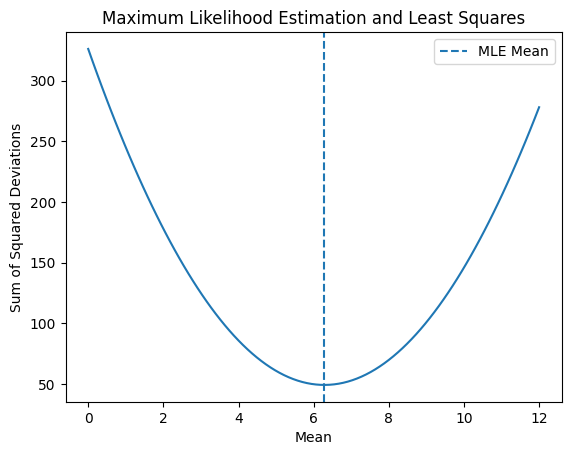

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
x = np.array([2, 4, 5, 6, 8, 9, 10])

# Maximum Likelihood Estimate of mean
mle_mean = np.mean(x)

print("Sample Data:", x)
print("MLE Mean:", mle_mean)

# Try different mean values
means = np.linspace(0, 12, 100)

# Calculate sum of squared deviations
errors = []

for m in means:
    error = np.sum((x - m) ** 2)
    errors.append(error)

# Find mean with minimum error
min_mean = means[np.argmin(errors)]

print("Least Squares Mean:", min_mean)
print("Minimum Sum of Squared Error:", min(errors))

# Plot
plt.plot(means, errors)
plt.xlabel("Mean")
plt.ylabel("Sum of Squared Deviations")
plt.title("Maximum Likelihood Estimation and Least Squares")
plt.axvline(mle_mean, linestyle="--", label="MLE Mean")
plt.legend()
plt.show()

Lab 19 — Mistake-Bound Model — Halving Algorithm Simulation

In [7]:
# Halving Algorithm Simulation

# Possible hypotheses
H = [
    [0, 0, 0, 0],
    [0, 0, 1, 1],
    [0, 1, 0, 1],
    [0, 1, 1, 0],
    [1, 0, 0, 1],
    [1, 0, 1, 0],
    [1, 1, 0, 0],
    [1, 1, 1, 1]
]

# Actual target outputs
y = [0, 1, 1, 0]

# Number of mistakes
mistakes = 0

# Go through each example
for i in range(len(y)):

    votes = []

    # Get prediction from every hypothesis
    for h in H:
        votes.append(h[i])

    # Majority vote
    if votes.count(1) >= votes.count(0):
        prediction = 1
    else:
        prediction = 0

    print("Example", i + 1)
    print("Prediction:", prediction)
    print("Actual:", y[i])

    # If prediction is wrong
    if prediction != y[i]:

        mistakes += 1

        # Remove hypotheses that predicted incorrectly
        new_H = []

        for h in H:
            if h[i] == y[i]:
                new_H.append(h)

        H = new_H

        print("Mistake! Hypotheses eliminated.")

    print("Remaining hypotheses:", len(H))
    print()

# Final result
print("Total Mistakes:", mistakes)
print("Final Version Space:", H)

Example 1
Prediction: 1
Actual: 0
Mistake! Hypotheses eliminated.
Remaining hypotheses: 4

Example 2
Prediction: 1
Actual: 1
Remaining hypotheses: 4

Example 3
Prediction: 1
Actual: 1
Remaining hypotheses: 4

Example 4
Prediction: 1
Actual: 0
Mistake! Hypotheses eliminated.
Remaining hypotheses: 2

Total Mistakes: 2
Final Version Space: [[0, 0, 0, 0], [0, 1, 1, 0]]


Lab 20 — Sample Complexity / PAC Bound Calculator

In [8]:
import math

# Get input values
H = int(input("Enter size of hypothesis space |H|: "))
epsilon = float(input("Enter epsilon: "))
delta = float(input("Enter delta: "))

# Calculate PAC bound
m = (1 / epsilon) * (
    math.log(H) + math.log(1 / delta)
)

# Round up to nearest integer
m = math.ceil(m)

# Display result
print("\nRequired number of training examples:", m)

Enter size of hypothesis space |H|: 100
Enter epsilon: 0.1
Enter delta: 0.05

Required number of training examples: 77


Lab 21 — K-Nearest Neighbour Classifier (Iris Dataset)

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN model
model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Print correct and wrong predictions
for i in range(len(y_test)):

    actual = iris.target_names[y_test[i]]
    predicted = iris.target_names[y_pred[i]]

    if y_test[i] == y_pred[i]:
        result = "Correct"
    else:
        result = "Wrong"

    print("Actual:", actual)
    print("Predicted:", predicted)
    print("Result:", result)
    print()

# Calculate accuracy
accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Actual: versicolor
Predicted: versicolor
Result: Correct

Actual: setosa
Predicted: setosa
Result: Correct

Actual: virginica
Predicted: virginica
Result: Correct

Actual: versicolor
Predicted: versicolor
Result: Correct

Actual: versicolor
Predicted: versicolor
Result: Correct

Actual: setosa
Predicted: setosa
Result: Correct

Actual: versicolor
Predicted: versicolor
Result: Correct

Actual: virginica
Predicted: virginica
Result: Correct

Actual: versicolor
Predicted: versicolor
Result: Correct

Actual: versicolor
Predicted: versicolor
Result: Correct

Actual: virginica
Predicted: virginica
Result: Correct

Actual: setosa
Predicted: setosa
Result: Correct

Actual: setosa
Predicted: setosa
Result: Correct

Actual: setosa
Predicted: setosa
Result: Correct

Actual: setosa
Predicted: setosa
Result: Correct

Actual: versicolor
Predicted: versicolor
Result: Correct

Actual: virginica
Predicted: virginica
Result: Correct

Actual: versicolor
Predicted: versicolor
Result: Correct

Actual: vers

Lab 22 — K-Nearest Neighbour Regression

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Sample input data
X = np.array([
    [1], [2], [3], [4], [5],
    [6], [7], [8], [9], [10]
])

# Continuous target values
y = np.array([
    2, 4, 6, 8, 10,
    12, 14, 16, 18, 20
])

# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN Regression model
model = KNeighborsRegressor(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

# Predict test values
y_pred = model.predict(X_test)

# Print actual and predicted values
for i in range(len(y_test)):
    print("Actual:", y_test[i])
    print("Predicted:", y_pred[i])
    print()

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

# Predict a new value
new_x = np.array([[5.5]])

prediction = model.predict(new_x)

print("Prediction for 5.5:", prediction[0])

Actual: 18
Predicted: 16.666666666666668

Actual: 4
Predicted: 5.333333333333333

Mean Squared Error: 1.777777777777776
Prediction for 5.5: 10.0


Lab 23 — Distance-Weighted KNN

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Uniform-weighted KNN
uniform_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="uniform"
)

uniform_model.fit(X_train, y_train)

uniform_pred = uniform_model.predict(X_test)

uniform_accuracy = accuracy_score(y_test, uniform_pred)


# Distance-weighted KNN
distance_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)

distance_model.fit(X_train, y_train)

distance_pred = distance_model.predict(X_test)

distance_accuracy = accuracy_score(y_test, distance_pred)


# Print results
print("Uniform Weighted KNN Accuracy:", uniform_accuracy)

print("Distance Weighted KNN Accuracy:", distance_accuracy)


# Compare predictions
print("\nActual | Uniform | Distance")

for i in range(len(y_test)):
    print(
        iris.target_names[y_test[i]],
        "|",
        iris.target_names[uniform_pred[i]],
        "|",
        iris.target_names[distance_pred[i]]
    )

Uniform Weighted KNN Accuracy: 1.0
Distance Weighted KNN Accuracy: 1.0

Actual | Uniform | Distance
versicolor | versicolor | versicolor
setosa | setosa | setosa
virginica | virginica | virginica
versicolor | versicolor | versicolor
versicolor | versicolor | versicolor
setosa | setosa | setosa
versicolor | versicolor | versicolor
virginica | virginica | virginica
versicolor | versicolor | versicolor
versicolor | versicolor | versicolor
virginica | virginica | virginica
setosa | setosa | setosa
setosa | setosa | setosa
setosa | setosa | setosa
setosa | setosa | setosa
versicolor | versicolor | versicolor
virginica | virginica | virginica
versicolor | versicolor | versicolor
versicolor | versicolor | versicolor
virginica | virginica | virginica
setosa | setosa | setosa
virginica | virginica | virginica
setosa | setosa | setosa
virginica | virginica | virginica
virginica | virginica | virginica
virginica | virginica | virginica
virginica | virginica | virginica
virginica | virginica | vir

Lab 24 — Locally Weighted Regression (LWR) from Scratch


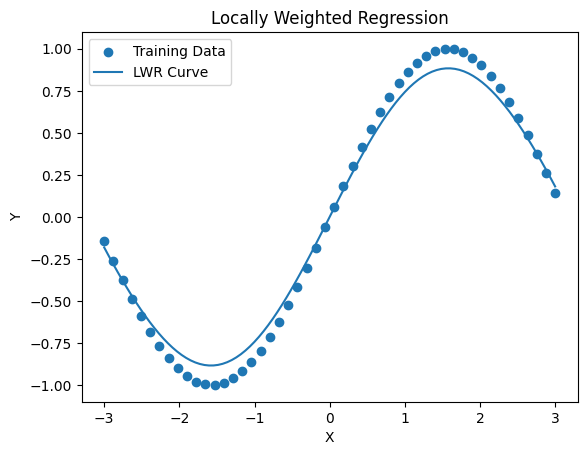

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Training data
x = np.linspace(-3, 3, 50)
y = np.sin(x)

# Add bias term
X = np.column_stack((np.ones(len(x)), x))

# Bandwidth value
tau = 0.5


# Locally Weighted Regression function
def lwr(query):

    # Calculate Gaussian weights
    w = np.exp(-(x - query) ** 2 / (2 * tau ** 2))

    # Create diagonal weight matrix
    W = np.diag(w)

    # Calculate local linear model
    theta = np.linalg.pinv(X.T @ W @ X) @ X.T @ W @ y

    # Predict value
    prediction = theta[0] + theta[1] * query

    return prediction


# Query points for prediction
x_test = np.linspace(-3, 3, 100)

# Store predictions
y_pred = []

for q in x_test:
    y_pred.append(lwr(q))


# Plot results
plt.scatter(x, y, label="Training Data")
plt.plot(x_test, y_pred, label="LWR Curve")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Locally Weighted Regression")
plt.legend()

plt.show()

Lab 25 — Radial Basis Function (RBF) Network

In [13]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Select RBF centres using K-Means
k = 10

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train)

centers = kmeans.cluster_centers_

# Gaussian RBF function
def rbf(X, centers, sigma=1.0):

    features = []

    for x in X:
        row = []

        for c in centers:
            distance = np.linalg.norm(x - c)

            value = np.exp(-(distance ** 2) / (2 * sigma ** 2))

            row.append(value)

        features.append(row)

    return np.array(features)

# Transform training and testing data
X_train_rbf = rbf(X_train, centers)
X_test_rbf = rbf(X_test, centers)

# Train linear classifier
model = LogisticRegression(max_iter=1000)

model.fit(X_train_rbf, y_train)

# Predict test data
y_pred = model.predict(X_test_rbf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Print some predictions
print("\nActual | Predicted")

for i in range(len(y_test)):
    print(
        iris.target_names[y_test[i]],
        "|",
        iris.target_names[y_pred[i]]
    )

Accuracy: 1.0

Actual | Predicted
versicolor | versicolor
setosa | setosa
virginica | virginica
versicolor | versicolor
versicolor | versicolor
setosa | setosa
versicolor | versicolor
virginica | virginica
versicolor | versicolor
versicolor | versicolor
virginica | virginica
setosa | setosa
setosa | setosa
setosa | setosa
setosa | setosa
versicolor | versicolor
virginica | virginica
versicolor | versicolor
versicolor | versicolor
virginica | virginica
setosa | setosa
virginica | virginica
setosa | setosa
virginica | virginica
virginica | virginica
virginica | virginica
virginica | virginica
virginica | virginica
setosa | setosa
setosa | setosa


Lab 26 — Case-Based Reasoning (Simple CBR System)

In [14]:
# Past cases
cases = [
    {
        "features": {
            "fever": "yes",
            "cough": "yes",
            "headache": "yes"
        },
        "solution": "Flu"
    },
    {
        "features": {
            "fever": "yes",
            "cough": "no",
            "headache": "yes"
        },
        "solution": "Viral Fever"
    },
    {
        "features": {
            "fever": "no",
            "cough": "yes",
            "headache": "no"
        },
        "solution": "Common Cold"
    }
]

# New problem
new_case = {
    "fever": "yes",
    "cough": "yes",
    "headache": "no"
}

# Find similarity
def similarity(case, new_case):
    score = 0

    for feature in new_case:
        if case["features"][feature] == new_case[feature]:
            score += 1

    return score


# Find the most similar case
best_case = None
best_score = -1

for case in cases:
    score = similarity(case, new_case)

    print("Case:", case["features"])
    print("Solution:", case["solution"])
    print("Similarity Score:", score)
    print()

    if score > best_score:
        best_score = score
        best_case = case


# Reuse the solution
solution = best_case["solution"]

print("New Problem:", new_case)
print("Most Similar Case:", best_case["features"])
print("Solution:", solution)


# Retain the new case
cases.append({
    "features": new_case,
    "solution": solution
})

print("\nNew case added successfully!")

Case: {'fever': 'yes', 'cough': 'yes', 'headache': 'yes'}
Solution: Flu
Similarity Score: 2

Case: {'fever': 'yes', 'cough': 'no', 'headache': 'yes'}
Solution: Viral Fever
Similarity Score: 1

Case: {'fever': 'no', 'cough': 'yes', 'headache': 'no'}
Solution: Common Cold
Similarity Score: 2

New Problem: {'fever': 'yes', 'cough': 'yes', 'headache': 'no'}
Most Similar Case: {'fever': 'yes', 'cough': 'yes', 'headache': 'yes'}
Solution: Flu

New case added successfully!


Lab 27 — NumPy Array Creation and Basic Operations

In [15]:
import numpy as np

# Create array using np.array
a = np.array([1, 2, 3, 4, 5])
print("Array:", a)

# Create array of zeros
b = np.zeros(5)
print("Zeros:", b)

# Create array of ones
c = np.ones(5)
print("Ones:", c)

# Create array using arange
d = np.arange(1, 10, 2)
print("Arange:", d)

# Create array using linspace
e = np.linspace(0, 10, 5)
print("Linspace:", e)


# Basic arithmetic operations
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

print("\nAddition:", x + y)
print("Subtraction:", x - y)
print("Multiplication:", x * y)
print("Division:", x / y)


# Dot product
print("\nDot Product:", np.dot(x, y))


# Universal functions
print("\nSquare Root:", np.sqrt(x))
print("Square:", np.square(x))
print("Exponential:", np.exp(x))
print("Logarithm:", np.log(x))

Array: [1 2 3 4 5]
Zeros: [0. 0. 0. 0. 0.]
Ones: [1. 1. 1. 1. 1.]
Arange: [1 3 5 7 9]
Linspace: [ 0.   2.5  5.   7.5 10. ]

Addition: [5 7 9]
Subtraction: [-3 -3 -3]
Multiplication: [ 4 10 18]
Division: [0.25 0.4  0.5 ]

Dot Product: 32

Square Root: [1.         1.41421356 1.73205081]
Square: [1 4 9]
Exponential: [ 2.71828183  7.3890561  20.08553692]
Logarithm: [0.         0.69314718 1.09861229]


Lab 28 — NumPy Indexing and Filtering

In [16]:
import numpy as np

# Create and reshape array into 2D
a = np.arange(1, 17).reshape(4, 4)

print("Original Array:")
print(a)

# Indexing
print("\nElement at row 2, column 3:", a[1, 2])

# First row
print("\nFirst Row:")
print(a[0])

# Second column
print("\nSecond Column:")
print(a[:, 1])

# Slicing
print("\nFirst 2 Rows:")
print(a[:2])

print("\nFirst 2 Columns:")
print(a[:, :2])

# Sub-array
print("\nSub Array:")
print(a[1:3, 1:3])

# Boolean filtering
print("\nElements greater than 10:")
print(a[a > 10])

# Even numbers
print("\nEven Numbers:")
print(a[a % 2 == 0])

Original Array:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

Element at row 2, column 3: 7

First Row:
[1 2 3 4]

Second Column:
[ 2  6 10 14]

First 2 Rows:
[[1 2 3 4]
 [5 6 7 8]]

First 2 Columns:
[[ 1  2]
 [ 5  6]
 [ 9 10]
 [13 14]]

Sub Array:
[[ 6  7]
 [10 11]]

Elements greater than 10:
[11 12 13 14 15 16]

Even Numbers:
[ 2  4  6  8 10 12 14 16]


Lab 29 — NumPy Statistics and Aggregation

In [17]:
import numpy as np

# Create a 2D array
a = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

print("Array:")
print(a)

# Mean
print("\nMean:", a.mean())

# Total sum
print("Total Sum:", a.sum())

# Sum of each column
print("Column-wise Sum:", a.sum(axis=0))

# Sum of each row
print("Row-wise Sum:", a.sum(axis=1))

# Standard deviation
print("Standard Deviation:", a.std())

# Minimum value
print("Minimum:", a.min())

# Maximum value
print("Maximum:", a.max())

Array:
[[10 20 30]
 [40 50 60]
 [70 80 90]]

Mean: 50.0
Total Sum: 450
Column-wise Sum: [120 150 180]
Row-wise Sum: [ 60 150 240]
Standard Deviation: 25.81988897471611
Minimum: 10
Maximum: 90


Lab 30 — NumPy Random Module for Simulation

In [18]:
import numpy as np

# Create a seeded random generator
rng = np.random.default_rng(42)

# Generate uniform random numbers
uniform = rng.random(5)

# Generate random integers
integers = rng.integers(1, 100, 5)

# Generate normally distributed random numbers
normal = rng.normal(0, 1, 5)

# Print results
print("Uniform Random Numbers:")
print(uniform)

print("\nRandom Integers:")
print(integers)

print("\nNormally Distributed Random Numbers:")
print(normal)

Uniform Random Numbers:
[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]

Random Integers:
[53 97 73 76 72]

Normally Distributed Random Numbers:
[-0.01680116 -0.85304393  0.87939797  0.77779194  0.0660307 ]


Lab 31 — Saving and Loading Data with NumPy

In [19]:
import numpy as np

# Create a NumPy array
a = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

print("Original Array:")
print(a)

# Save array in binary format
np.save("data.npy", a)

# Load binary file
b = np.load("data.npy")

print("\nLoaded from .npy file:")
print(b)


# Save array in CSV text format
np.savetxt("data.csv", a, delimiter=",")

# Load CSV file
c = np.loadtxt("data.csv", delimiter=",")

print("\nLoaded from CSV file:")
print(c)

Original Array:
[[10 20 30]
 [40 50 60]
 [70 80 90]]

Loaded from .npy file:
[[10 20 30]
 [40 50 60]
 [70 80 90]]

Loaded from CSV file:
[[10. 20. 30.]
 [40. 50. 60.]
 [70. 80. 90.]]


Lab 32 — Pandas DataFrame Creation and Combining

In [20]:
import pandas as pd

# Create first DataFrame from dictionary
data1 = {
    "ID": [1, 2, 3],
    "Name": ["A", "B", "C"],
    "Age": [20, 21, 22]
}

df1 = pd.DataFrame(data1)

print("DataFrame 1:")
print(df1)


# Create second DataFrame from dictionary
data2 = {
    "ID": [4, 5, 6],
    "Name": ["D", "E", "F"],
    "Age": [23, 24, 25]
}

df2 = pd.DataFrame(data2)

print("\nDataFrame 2:")
print(df2)


# Combine DataFrames using concat
combined = pd.concat([df1, df2])

print("\nCombined using Concat:")
print(combined)


# Create another DataFrame for merging
data3 = {
    "ID": [1, 2, 3],
    "Department": ["IT", "CSE", "ECE"]
}

df3 = pd.DataFrame(data3)

print("\nDataFrame 3:")
print(df3)


# Merge DataFrames using common key
merged = pd.merge(df1, df3, on="ID")

print("\nMerged DataFrame:")
print(merged)

DataFrame 1:
   ID Name  Age
0   1    A   20
1   2    B   21
2   3    C   22

DataFrame 2:
   ID Name  Age
0   4    D   23
1   5    E   24
2   6    F   25

Combined using Concat:
   ID Name  Age
0   1    A   20
1   2    B   21
2   3    C   22
0   4    D   23
1   5    E   24
2   6    F   25

DataFrame 3:
   ID Department
0   1         IT
1   2        CSE
2   3        ECE

Merged DataFrame:
   ID Name  Age Department
0   1    A   20         IT
1   2    B   21        CSE
2   3    C   22        ECE


Lab 33 — Pandas File I/O (Reading and Writing CSV)

In [21]:
import pandas as pd
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Read CSV file
df = pd.read_csv(file_name)

print("Original Data:")
print(df)

# Example: Show first 5 rows
processed_df = df.head()

print("\nProcessed Data:")
print(processed_df)

# Save processed DataFrame to a new CSV file
processed_df.to_csv("output.csv", index=False)

print("\nFile saved successfully as output.csv")

# Download the output file
files.download("output.csv")

Saving data.csv to data (3).csv
Original Data:
     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No

Processed Data:
    Outlook Temperature Humidity    Wind Play
0     Sunny         Hot     High    Weak   No
1     Sunny         Hot     High  Strong   No
2  Overcast         Hot     High    Weak  Yes
3      Rain        Mild     High    Weak  Yes
4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Lab 34 — Pandas Grouping and Aggregation

In [22]:
import pandas as pd

# Create DataFrame
data = {
    "Department": ["IT", "CSE", "IT", "CSE", "ECE", "IT"],
    "Marks": [80, 75, 90, 85, 70, 95]
}

df = pd.DataFrame(data)

print("Original Data:")
print(df)

# Group by Department and find mean
print("\nMean Marks:")
print(df.groupby("Department")["Marks"].mean())

# Group by Department and find sum
print("\nTotal Marks:")
print(df.groupby("Department")["Marks"].sum())

# Multiple aggregation functions
print("\nMultiple Aggregations:")
print(df.groupby("Department")["Marks"].agg(["mean", "sum", "min", "max"]))

Original Data:
  Department  Marks
0         IT     80
1        CSE     75
2         IT     90
3        CSE     85
4        ECE     70
5         IT     95

Mean Marks:
Department
CSE    80.000000
ECE    70.000000
IT     88.333333
Name: Marks, dtype: float64

Total Marks:
Department
CSE    160
ECE     70
IT     265
Name: Marks, dtype: int64

Multiple Aggregations:
                 mean  sum  min  max
Department                          
CSE         80.000000  160   75   85
ECE         70.000000   70   70   70
IT          88.333333  265   80   95


Lab 35 — Pandas Filtering and Sorting

In [23]:
import pandas as pd

# Create DataFrame
data = {
    "Name": ["A", "B", "C", "D", "E"],
    "Age": [20, 22, 19, 21, 23],
    "Marks": [85, 70, 90, 75, 95]
}

df = pd.DataFrame(data)

print("Original Data:")
print(df)

# Filter rows with Marks greater than 80
print("\nStudents with Marks > 80:")
print(df[df["Marks"] > 80])

# Filter using multiple conditions
print("\nMarks > 75 and Age > 20:")
print(df[(df["Marks"] > 75) & (df["Age"] > 20)])

# Filter using OR condition
print("\nMarks > 90 or Age < 20:")
print(df[(df["Marks"] > 90) | (df["Age"] < 20)])

# Sort by Marks
print("\nSorted by Marks:")
print(df.sort_values("Marks"))

# Sort by multiple columns
print("\nSorted by Age and Marks:")
print(df.sort_values(["Age", "Marks"]))

Original Data:
  Name  Age  Marks
0    A   20     85
1    B   22     70
2    C   19     90
3    D   21     75
4    E   23     95

Students with Marks > 80:
  Name  Age  Marks
0    A   20     85
2    C   19     90
4    E   23     95

Marks > 75 and Age > 20:
  Name  Age  Marks
4    E   23     95

Marks > 90 or Age < 20:
  Name  Age  Marks
2    C   19     90
4    E   23     95

Sorted by Marks:
  Name  Age  Marks
1    B   22     70
3    D   21     75
0    A   20     85
2    C   19     90
4    E   23     95

Sorted by Age and Marks:
  Name  Age  Marks
2    C   19     90
0    A   20     85
3    D   21     75
1    B   22     70
4    E   23     95


Lab 36 — Pandas Plotting (Data Visualisation)

Data:
  Name  Marks
0    A     85
1    B     70
2    C     90
3    D     75
4    E     95


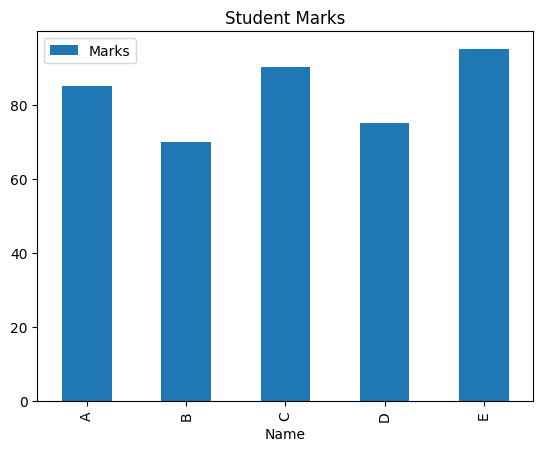

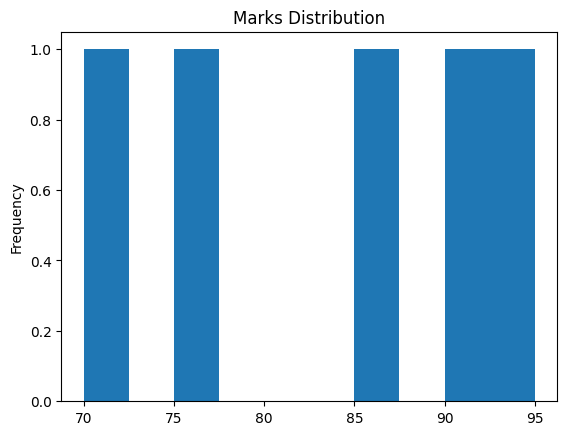

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
data = {
    "Name": ["A", "B", "C", "D", "E"],
    "Marks": [85, 70, 90, 75, 95]
}

df = pd.DataFrame(data)

print("Data:")
print(df)

# Bar Chart
df.plot(
    x="Name",
    y="Marks",
    kind="bar",
    title="Student Marks"
)

plt.show()

# Histogram
df["Marks"].plot(
    kind="hist",
    title="Marks Distribution"
)

plt.show()

Lab 37 — Data Cleaning with Pandas (Missing Values & Duplicates)

In [25]:
import pandas as pd

# Create DataFrame with missing values and duplicates
data = {
    "Name": ["A", "B", "C", "D", "B"],
    "Age": [20, 21, None, 22, 21],
    "Marks": [80, None, 90, 85, None]
}

df = pd.DataFrame(data)

print("Original Data:")
print(df)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Marks"] = df["Marks"].fillna(df["Marks"].mean())

print("\nAfter Filling Missing Values:")
print(df)

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nAfter Removing Duplicates:")
print(df)

Original Data:
  Name   Age  Marks
0    A  20.0   80.0
1    B  21.0    NaN
2    C   NaN   90.0
3    D  22.0   85.0
4    B  21.0    NaN

Missing Values:
Name     0
Age      1
Marks    2
dtype: int64

After Filling Missing Values:
  Name   Age  Marks
0    A  20.0   80.0
1    B  21.0   85.0
2    C  21.0   90.0
3    D  22.0   85.0
4    B  21.0   85.0

Duplicate Rows:
0    False
1    False
2    False
3    False
4     True
dtype: bool

After Removing Duplicates:
  Name   Age  Marks
0    A  20.0   80.0
1    B  21.0   85.0
2    C  21.0   90.0
3    D  22.0   85.0


Lab 38 — End-to-End Mini ML Pipeline (Load → Clean → Train → Predict)

In [26]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Upload CSV file
uploaded = files.upload()

# Get file name
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

print("Original Data:")
print(df.head())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

print("\nCleaned Data:")
print(df.head())

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN model
model = KNeighborsClassifier(n_neighbors=3)

# Train model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display predictions
print("\nActual | Predicted")

for i in range(len(y_test)):
    print(y_test.iloc[i], "|", y_pred[i])

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# Predict a new sample
new_sample = [X.iloc[0].values]

prediction = model.predict(new_sample)

print("\nNew Sample Prediction:", prediction[0])

Saving data.csv to data (4).csv
Original Data:
    Outlook Temperature Humidity    Wind Play
0     Sunny         Hot     High    Weak   No
1     Sunny         Hot     High  Strong   No
2  Overcast         Hot     High    Weak  Yes
3      Rain        Mild     High    Weak  Yes
4      Rain        Cool   Normal    Weak  Yes

Missing Values:
Outlook        0
Temperature    0
Humidity       0
Wind           0
Play           0
dtype: int64

Cleaned Data:
   Outlook  Temperature  Humidity  Wind  Play
0        2            1         0     1     0
1        2            1         0     0     0
2        0            1         0     1     1
3        1            2         0     1     1
4        1            0         1     1     1

Actual | Predicted
1 | 1
1 | 1
0 | 0

Accuracy: 1.0

New Sample Prediction: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Lab 39 — Model Evaluation Metrics (Confusion Matrix, Precision, Recall, F1)

In [27]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train KNN model
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(
    y_test, y_pred, average="weighted"
)

# Recall
recall = recall_score(
    y_test, y_pred, average="weighted"
)

# F1 Score
f1 = f1_score(
    y_test, y_pred, average="weighted"
)

# Print results
print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


Lab 40 — Capstone: Complete Machine Learning Pipeline with Visualisation

Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Decision Tree Accuracy: 1.0
KNN Accuracy: 1.0

Actual | Decision Tree | KNN
versicolor | versicolor | versicolor
setosa | setosa | setosa
virginica | virginica | virginica
versicolor | versicolor | versicolor
versicolor | versicolor | versicolor
setosa | setosa | setosa
versicolor | versicolor | v

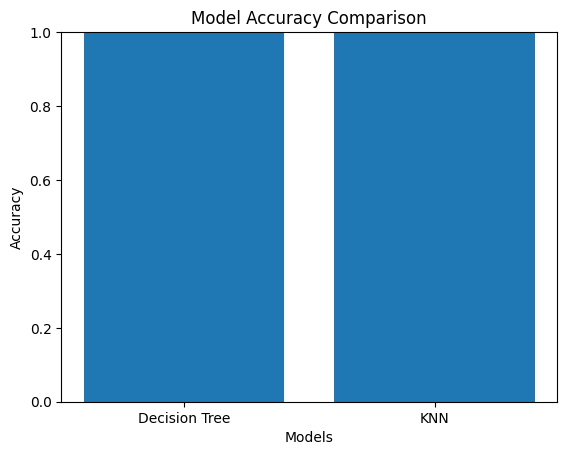

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()

# Convert to Pandas DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df["target"] = iris.target

# Display first 5 rows
print("Dataset:")
print(df.head())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# NumPy operation - convert to NumPy array
X = np.array(X)
y = np.array(y)

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

# Print accuracies
print("\nDecision Tree Accuracy:", dt_accuracy)
print("KNN Accuracy:", knn_accuracy)

# Compare predictions
print("\nActual | Decision Tree | KNN")

for i in range(len(y_test)):
    print(
        iris.target_names[y_test[i]],
        "|",
        iris.target_names[dt_pred[i]],
        "|",
        iris.target_names[knn_pred[i]]
    )

# Visualisation
models = ["Decision Tree", "KNN"]
accuracy = [dt_accuracy, knn_accuracy]

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 1)
plt.show()